# Ejercicio 4 - Analisis exploratorio con DuckDB

Todas las consultas estan en `sql/04_*.sql` y se imprimen al ejecutarlas. Salvo indicacion, usan `trips_clean`
(ver Ejercicio 3). Colores: amarillo = taxi amarillo, verde = taxi verde.

## 4.1 Preguntas

1. Como evoluciona el volumen de viajes mes a mes? (temporal)
2. A que horas y en que dias se concentra la demanda de cada taxi? (temporal)
3. Como se distribuyen distancia y duracion? (caracteristicas / distribucion)
4. En que se diferencian taxis amarillos y verdes? (comparacion)
5. Como pagan y cuanta propina dejan? (pago)
6. Que zonas concentran mas recogidas? (geografia)
7. Cuantos valores atipicos o inconsistentes persisten tras la limpieza basica? (calidad)

La justificacion: el conjunto tiene fechas, distancias, montos, tipo de pago y zonas; son las dimensiones naturales
para describir un servicio de transporte y para detectar errores de captura.

In [1]:
import sys; sys.path.insert(0, "../scripts")
import labutil as lu
import matplotlib.pyplot as plt
con = lu.connect()
COLOR = {"yellow": "#E8B400", "green": "#2E8B57"}
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

## P1. Evolucion mensual

-- 04_01_monthly.sql
-- Pregunta: como evoluciona el volumen de viajes mes a mes y por taxi?
-- Fuente: trips_clean (Parquet yellow + green).
SELECT data_year AS anio, data_month AS mes, taxi, count(*) AS viajes
FROM trips_clean GROUP BY ALL ORDER BY anio, mes, taxi;



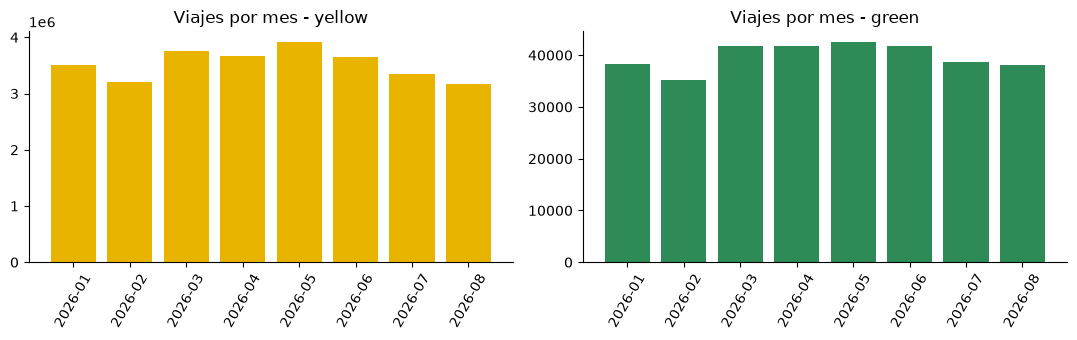

In [2]:
m = lu.q(con, "04_01_monthly.sql")
m["periodo"] = m.anio.astype(str) + "-" + m.mes.astype(str).str.zfill(2)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for t, g in m.groupby("taxi"):
    ax[0 if t == "yellow" else 1].bar(g.periodo, g.viajes, color=COLOR[t])
    ax[0 if t == "yellow" else 1].set_title(f"Viajes por mes - {t}")
    ax[0 if t == "yellow" else 1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

**Interpretacion:** yellow oscila entre 3.2 y 3.9 M de viajes/mes, con minimo en febrero (mes corto) y maximo en mayo; julio y agosto
bajan (vacaciones de verano). Green sigue el mismo patron a escala ~1% del volumen.

## P2. Hora del dia y dia de la semana

-- 04_02_hourly.sql
-- Pregunta: a que horas del dia se concentra la demanda de cada taxi?
-- Fuente: trips_clean.
SELECT taxi, hour(pickup) AS hora, count(*) AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY taxi), 2) AS pct_del_taxi
FROM trips_clean GROUP BY taxi, hour(pickup) ORDER BY taxi, hora;



-- 04_03_weekday.sql
-- Pregunta: cambia la demanda entre dias de semana y fines de semana?
-- Fuente: trips_clean. isodow: 1 = lunes ... 7 = domingo.
SELECT taxi, isodow(pickup) AS dia_semana, count(*) AS viajes,
       round(avg(fare_amount), 2) AS tarifa_media
FROM trips_clean GROUP BY ALL ORDER BY taxi, dia_semana;



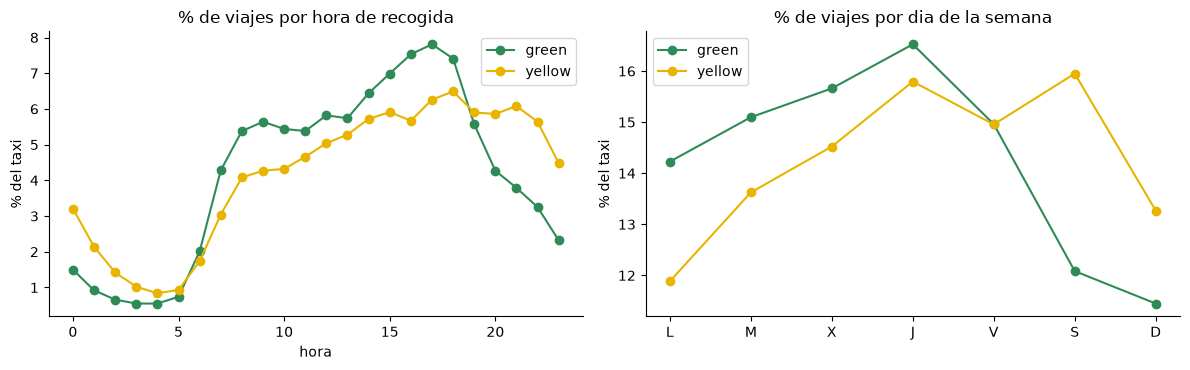

In [3]:
h = lu.q(con, "04_02_hourly.sql")
w = lu.q(con, "04_03_weekday.sql")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for t, g in h.groupby("taxi"):
    ax[0].plot(g.hora, g.pct_del_taxi, marker="o", color=COLOR[t], label=t)
ax[0].set(title="% de viajes por hora de recogida", xlabel="hora", ylabel="% del taxi"); ax[0].legend()
dias = ["L", "M", "X", "J", "V", "S", "D"]
for t, g in w.groupby("taxi"):
    ax[1].plot(dias, g.viajes / g.viajes.sum() * 100, marker="o", color=COLOR[t], label=t)
ax[1].set(title="% de viajes por dia de la semana", ylabel="% del taxi"); ax[1].legend()
plt.tight_layout(); plt.show()

**Interpretacion:** ambos taxis tienen su minimo de madrugada (3-5 h) y su maximo en la tarde (yellow: 18 h; green: 17 h), con un
pico matutino marcado en green (7-9 h, perfil de viaje al trabajo en los barrios exteriores). Yellow tiene mas actividad nocturna
(21-22 h) y su dia mas fuerte es el **sabado**, mientras que green cae en fines de semana (jueves es su pico).

## P3. Distancia y duracion

In [4]:
lu.q(con, "04_04_distance_dist.sql")

-- 04_04_distance_dist.sql
-- Pregunta: como se distribuyen la distancia y la duracion de los viajes?
-- Fuente: trips_clean.
SELECT taxi,
  round(avg(trip_distance), 2)                           AS dist_media,
  round(quantile_cont(trip_distance, 0.50), 2)           AS dist_p50,
  round(quantile_cont(trip_distance, 0.90), 2)           AS dist_p90,
  round(quantile_cont(trip_distance, 0.99), 2)           AS dist_p99,
  round(avg(date_diff('second', pickup, dropoff)) / 60, 1) AS dur_media_min,
  round(quantile_cont(date_diff('second', pickup, dropoff) / 60.0, 0.50), 1) AS dur_p50_min,
  round(quantile_cont(date_diff('second', pickup, dropoff) / 60.0, 0.99), 1) AS dur_p99_min
FROM trips_clean GROUP BY taxi;



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,taxi,dist_media,dist_p50,dist_p90,dist_p99,dur_media_min,dur_p50_min,dur_p99_min
0,green,3.30,2.12,7.33,17.62,17.0,13.2,73.6
1,yellow,3.52,1.93,8.70,19.56,17.7,14.1,71.3


-- 04_05_distance_hist.sql
-- Pregunta: cual es la forma de la distribucion de distancias (histograma)?
-- Fuente: trips_clean. Cajas de 1 milla hasta 20; el resto en 20+.
SELECT taxi, least(floor(trip_distance), 20)::INT AS milla, count(*) AS viajes
FROM trips_clean GROUP BY ALL ORDER BY taxi, milla;



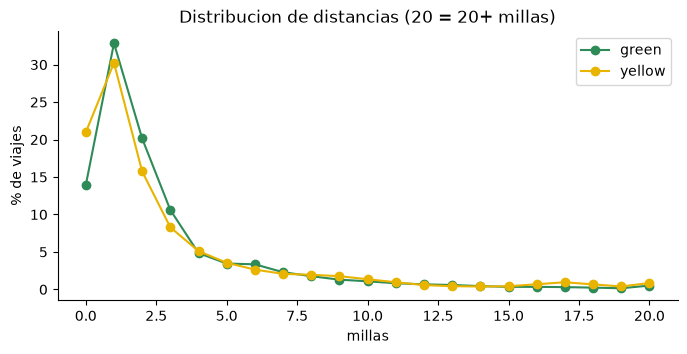

In [5]:
d = lu.q(con, "04_05_distance_hist.sql")
fig, ax = plt.subplots(figsize=(8, 3.5))
for t, g in d.groupby("taxi"):
    ax.plot(g.milla, g.viajes / g.viajes.sum() * 100, marker="o", color=COLOR[t], label=t)
ax.set(title="Distribucion de distancias (20 = 20+ millas)", xlabel="millas", ylabel="% de viajes"); ax.legend()
plt.show()

**Interpretacion:** distribucion muy sesgada a la derecha: la mediana (~2 millas, ~14 min) es mucho menor que la media (3.3-3.5 millas)
y el p99 llega a 18-20 millas. Por eso conviene reportar medianas/percentiles ademas de medias.

## P4. Amarillo vs verde

In [6]:
lu.q(con, "04_06_taxi_compare.sql").set_index("taxi").T

-- 04_06_taxi_compare.sql
-- Pregunta: en que se diferencian los taxis amarillos de los verdes?
-- Fuente: trips_clean.
SELECT taxi,
  count(*)                                                       AS viajes,
  round(avg(fare_amount), 2)                                     AS tarifa_media,
  round(avg(total_amount), 2)                                    AS total_medio,
  round(avg(trip_distance), 2)                                   AS dist_media,
  round(avg(fare_amount / trip_distance), 2)                     AS tarifa_por_milla,
  round(avg(trip_distance / (date_diff('second', pickup, dropoff) / 3600.0)), 1) AS velocidad_mph,
  round(avg(passenger_count), 2)                                 AS pasajeros_medios,
  round(100.0 * avg(CASE WHEN tolls_amount > 0 THEN 1 ELSE 0 END), 2) AS pct_con_peaje
FROM trips_clean GROUP BY taxi;



taxi,green,yellow
viajes,317987.00,28221859.00
tarifa_media,17.07,21.30
total_medio,25.40,30.25
dist_media,3.30,3.52
tarifa_por_milla,16.11,25.61
velocidad_mph,15.50,11.10
pasajeros_medios,1.30,1.25
pct_con_peaje,3.86,6.83


**Interpretacion:** el taxi verde tiene tarifa media menor (17.07 vs 21.30 USD) y mucho menor tarifa por milla (16 vs 26), pero
una velocidad media mayor (15.5 vs 11.1 mph): opera fuera del nucleo congestionado de Manhattan. Yellow usa mas peajes (6.8% vs 3.9%).
La tarifa por milla de yellow tambien refleja los viajes cortos con tarifa minima y recargos.

## P5. Pago y propinas

In [7]:
p = lu.q(con, "04_07_payment.sql"); p

-- 04_07_payment.sql
-- Pregunta: como pagan los pasajeros y cuanta propina dejan segun el medio?
-- Fuente: trips_clean. payment_type: 0 flex, 1 tarjeta, 2 efectivo, 3 sin cargo, 4 disputa, 5 desconocido, 6 anulado.
SELECT taxi,
  CASE payment_type WHEN 0 THEN '0 flex/app' WHEN 1 THEN '1 tarjeta' WHEN 2 THEN '2 efectivo'
       WHEN 3 THEN '3 sin cargo' WHEN 4 THEN '4 disputa' ELSE '5+ otro' END AS medio_pago,
  count(*) AS viajes,
  round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY taxi), 2) AS pct,
  round(avg(tip_amount), 2) AS propina_media,
  round(100 * avg(tip_amount / fare_amount), 2) AS propina_pct_tarifa
FROM trips_clean GROUP BY 1, 2 ORDER BY taxi, medio_pago;



,taxi,medio_pago,viajes,pct,propina_media,propina_pct_tarifa
0,green,1 tarjeta,211691,66.57,3.80,22.94
1,green,2 efectivo,62586,19.68,0.00,0.00
2,green,3 sin cargo,723,0.23,0.01,0.09
3,green,4 disputa,273,0.09,0.00,0.00
4,green,5+ otro,42714,13.43,0.84,3.20
5,yellow,0 flex/app,7036203,24.93,0.40,1.78
6,yellow,1 tarjeta,18456052,65.40,4.26,25.10
7,yellow,2 efectivo,2555338,9.05,0.00,0.00
8,yellow,3 sin cargo,56247,0.20,0.00,0.01
9,yellow,4 disputa,118019,0.42,0.00,0.01


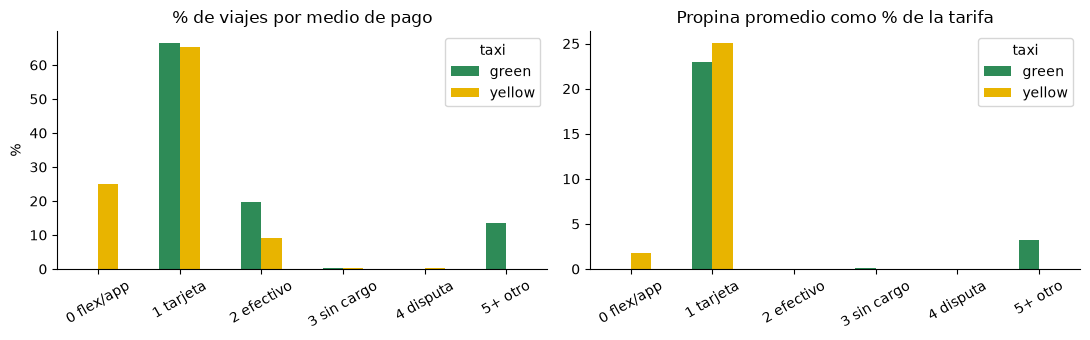

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
pv = p.pivot(index="medio_pago", columns="taxi", values="pct")
pv.plot.bar(ax=ax[0], color=[COLOR["green"], COLOR["yellow"]], rot=30); ax[0].set(title="% de viajes por medio de pago", xlabel="", ylabel="%")
pt = p.pivot(index="medio_pago", columns="taxi", values="propina_pct_tarifa")
pt.plot.bar(ax=ax[1], color=[COLOR["green"], COLOR["yellow"]], rot=30); ax[1].set(title="Propina promedio como % de la tarifa", xlabel="")
plt.tight_layout(); plt.show()

**Interpretacion:** la tarjeta domina (~65-67%). La propina en efectivo es 0 porque **no se registra** (no significa que no haya propina).
Con tarjeta la propina media es ~23-25% de la tarifa. Yellow tiene ~25% de viajes con `payment_type = 0` (flex/app), con propina casi nula.

## P6. Zonas

In [9]:
lu.q(con, "04_09_top_zones.sql")

-- 04_09_top_zones.sql
-- Pregunta: que zonas concentran mas recogidas?
-- Fuente: trips_clean. Se usan los IDs de zona de la TLC (no se descarga el catalogo).
SELECT taxi, pu_location AS zona, count(*) AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY taxi), 2) AS pct
FROM trips_clean GROUP BY taxi, pu_location QUALIFY row_number() OVER (PARTITION BY taxi ORDER BY viajes DESC) <= 10
ORDER BY taxi, viajes DESC;



,taxi,zona,viajes,pct
0,green,74,86913,27.33
1,green,75,41756,13.13
2,green,95,15632,4.92
3,green,43,12995,4.09
4,green,166,12448,3.91
5,green,82,11156,3.51
6,green,41,10984,3.45
7,green,65,10511,3.31
8,green,130,9175,2.89
9,green,97,8690,2.73


**Interpretacion:** green esta muy concentrado: la zona 74 (East Harlem North) acumula ~27% de las recogidas y las 3 primeras ~45%.
Yellow esta repartido: ninguna zona supera ~4.5% (zonas 237 y 161, Midtown/Upper East Side y aeropuertos).

## P7. Valores atipicos que sobreviven a la limpieza

In [10]:
lu.q(con, "04_08_outliers.sql")

-- 04_08_outliers.sql
-- Pregunta: cuantos valores atipicos hay y de que tipo?
-- Fuente: trips (sin limpiar) para medir lo que trips_clean elimina, mas velocidades en trips_clean.
SELECT 'velocidad > 80 mph (tras limpiar)' AS anomalia, count(*) AS viajes
FROM trips_clean WHERE trip_distance / (date_diff('second', pickup, dropoff) / 3600.0) > 80
UNION ALL SELECT 'tarifa > 200 USD (tras limpiar)', count(*) FROM trips_clean WHERE fare_amount > 200
UNION ALL SELECT 'propina > tarifa (tras limpiar)', count(*) FROM trips_clean WHERE tip_amount > fare_amount
UNION ALL SELECT 'pasajeros >= 7 (tras limpiar)', count(*) FROM trips_clean WHERE passenger_count >= 7
UNION ALL SELECT 'duracion < 1 min (tras limpiar)', count(*) FROM trips_clean WHERE dropoff - pickup < INTERVAL 1 MINUTE
UNION ALL SELECT 'recogida en pu_location 264/265 (desconocido)', count(*) FROM trips_clean WHERE pu_location IN (264, 265)
UNION ALL SELECT 'total < tarifa (tras limpiar)', count(*) FROM trips_clean WHERE total_amoun

,anomalia,viajes
0,velocidad > 80 mph (tras limpiar),8139
1,tarifa > 200 USD (tras limpiar),9856
2,propina > tarifa (tras limpiar),29297
3,pasajeros >= 7 (tras limpiar),87
4,duracion < 1 min (tras limpiar),90018
5,recogida en pu_location 264/265 (desconocido),36237
6,total < tarifa (tras limpiar),14389


**Interpretacion:** aun filtrado, quedan ~8 mil viajes a mas de 80 mph, ~90 mil con menos de 1 minuto, ~29 mil con propina mayor a la tarifa y
~36 mil recogidos en las zonas "desconocidas" 264/265. Son pocos frente a 28 M, pero distorsionan maximos; para medias y percentiles se mantienen
porque representan menos del 0.4%.

## 4.5 Hallazgos relevantes

1. **Dos servicios distintos:** yellow es ~99% de los viajes y opera en el centro (mas lento, mas caro por milla); green es 1% concentrado en pocas zonas exteriores, mas rapido y barato.
2. **Estacionalidad y patron semanal:** caida en julio-agosto y diferencia clara entre perfiles (yellow fuerte en sabado y noche; green laboral con pico matutino).
3. **~25% de yellow se registra como `payment_type = 0` y con campos nulos** (pasajeros, ratecode): un cambio de captura que sesga cualquier analisis de pasajeros o propinas si no se trata aparte.
4. **Las propinas en efectivo no existen en los datos**, por lo que la propina promedio global subestima la real; hay que condicionar a pago con tarjeta.
5. **Distribuciones muy sesgadas y ~5% de registros invalidos**, lo que justifica usar `trips_clean`, medianas y percentiles.